# California Housing Price Prediction

## 1. Import Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

## 2. Load Dataset

In [2]:
# ocean_proximity: categorical column
raw_data = pd.read_csv("housing.csv")
raw_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Exploratory Data Analysis

In [3]:
# total_bedrooms: total missing values 207
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
raw_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

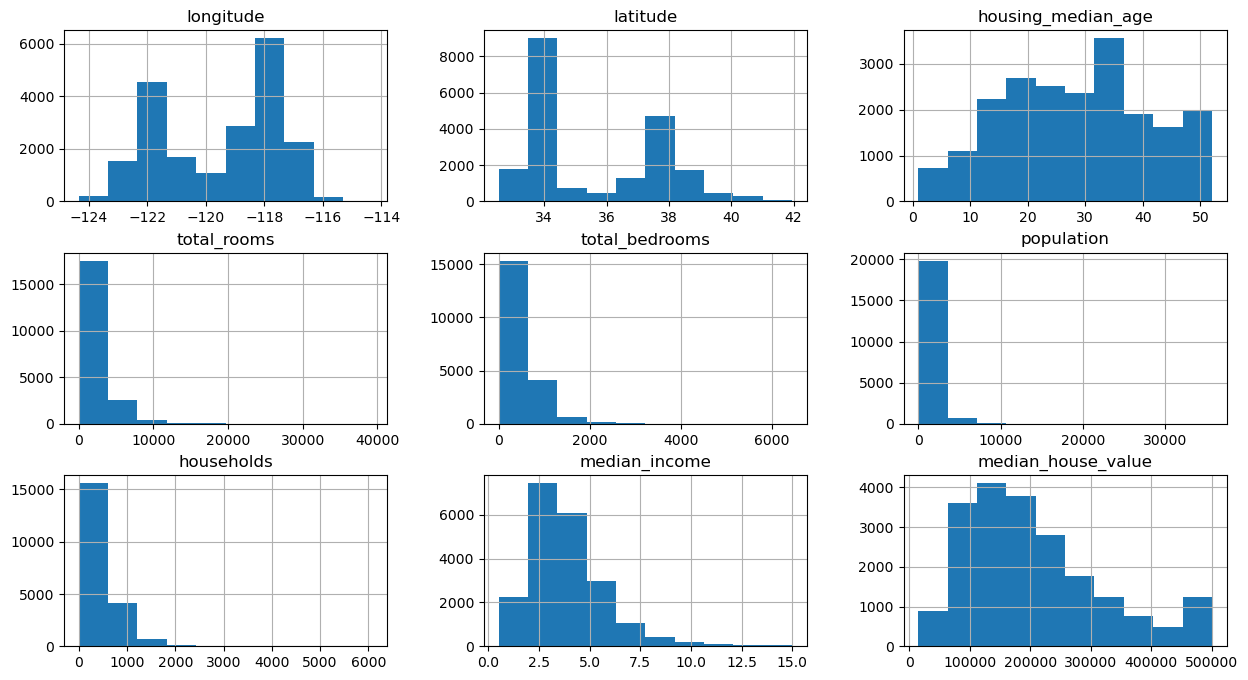

In [5]:
# total_rooms, total_bedrooms, population, households: needed to make gussian 
raw_data.hist(figsize=(15,8))

<Axes: >

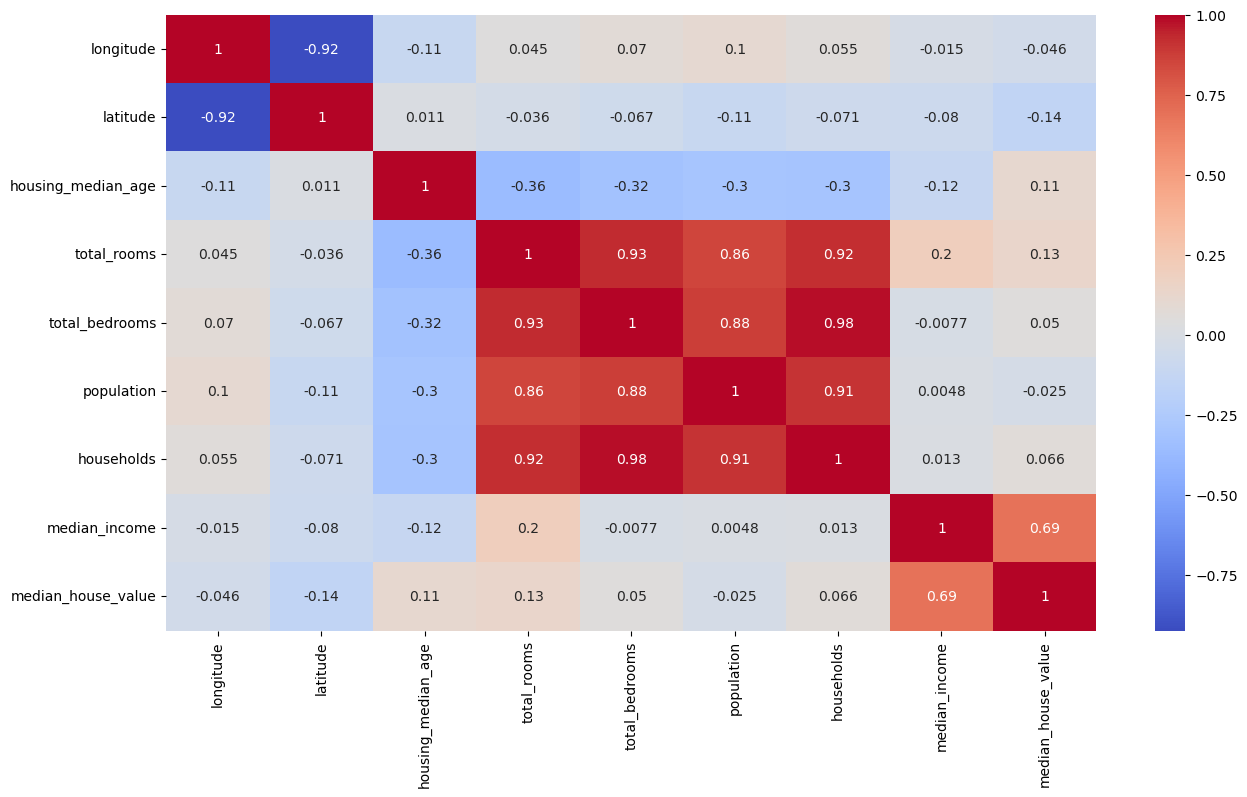

In [6]:
# some features are not effective, so have to do features engineering
plt.figure(figsize=(15,8))
sns.heatmap(data=raw_data.corr(numeric_only=True), annot=True, cmap="coolwarm")

<Axes: xlabel='longitude', ylabel='latitude'>

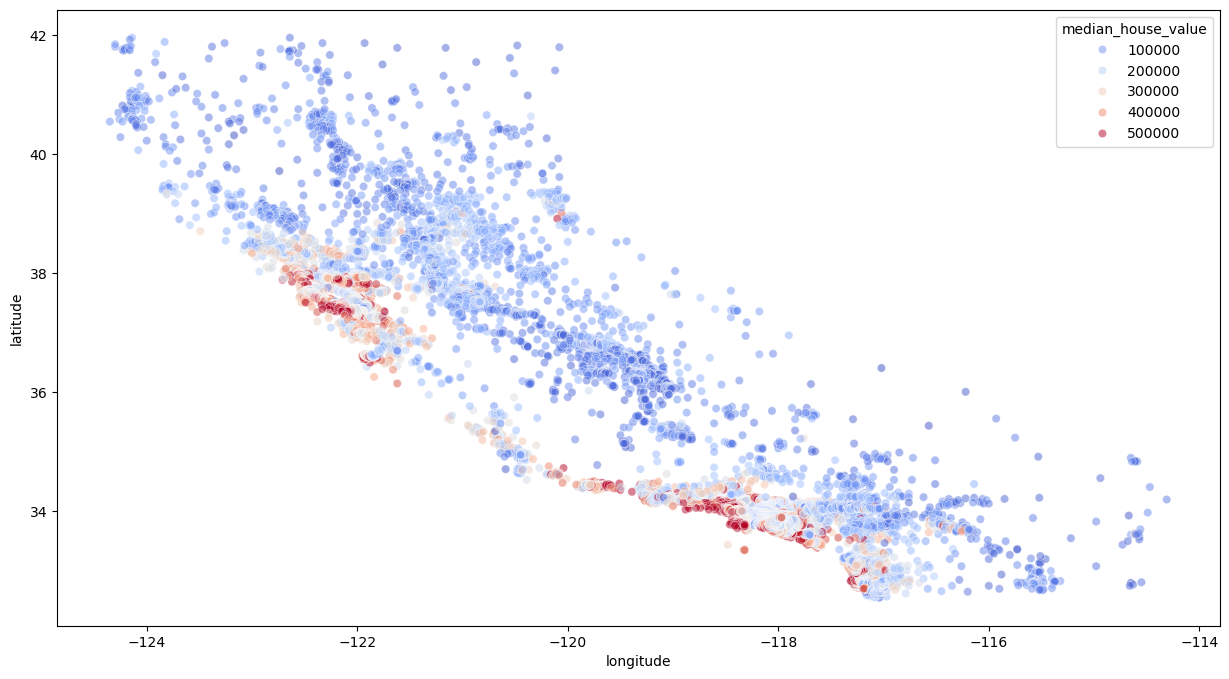

In [7]:
# so most of the expensive houses are besides the sea beach
plt.figure(figsize=(15,8))
sns.scatterplot(x="longitude",y="latitude", data=raw_data, hue="median_house_value" ,palette="coolwarm", alpha=0.5)

<Axes: xlabel='median_house_value', ylabel='Count'>

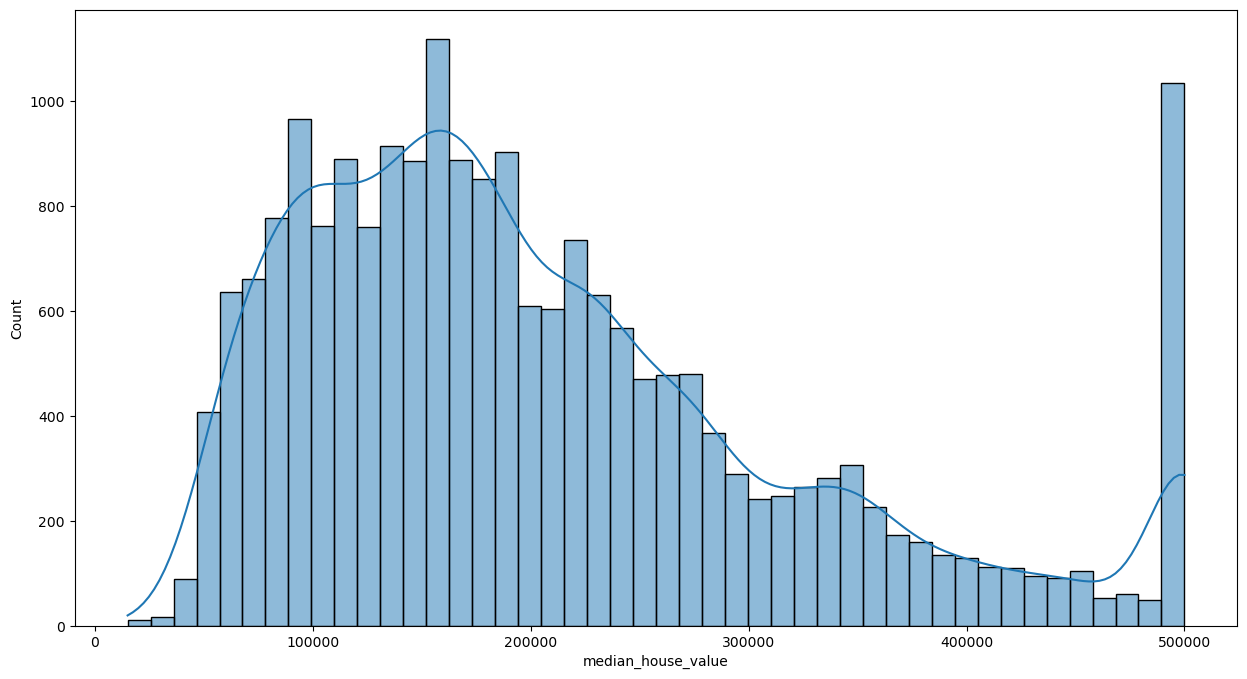

In [8]:
plt.figure(figsize=(15,8))
sns.histplot(raw_data["median_house_value"], kde=True)

<Axes: xlabel='median_income'>

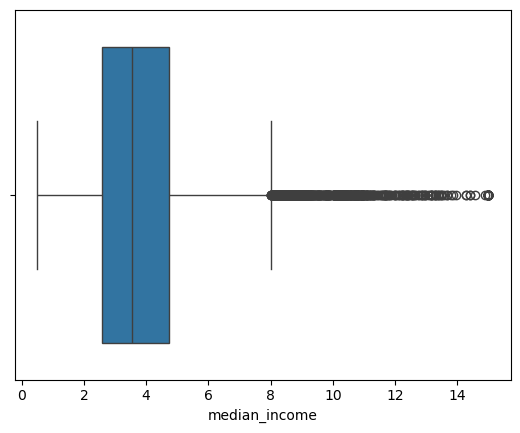

In [9]:
sns.boxplot(x=raw_data["median_income"])

<Axes: xlabel='ocean_proximity', ylabel='count'>

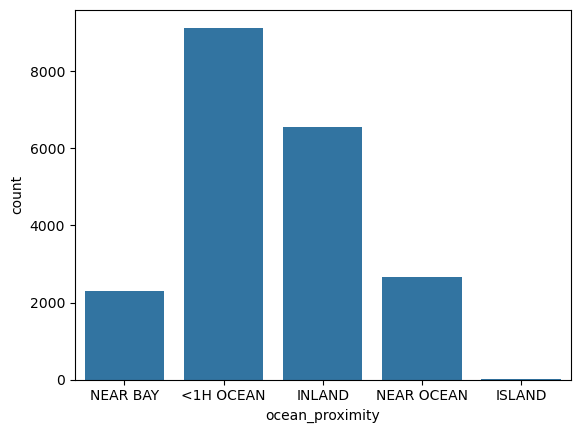

In [10]:
sns.countplot(
    data=raw_data,
    x="ocean_proximity"
)

## 4. Feature Engineering

In [11]:

raw_data["rooms_ratio"] = raw_data["total_rooms"]/raw_data["total_bedrooms"]
raw_data["holders_ratio"] = raw_data["households"]/raw_data["population"]
raw_data["median_income_ratio"] = raw_data["median_income"]/raw_data["population"]

<Axes: >

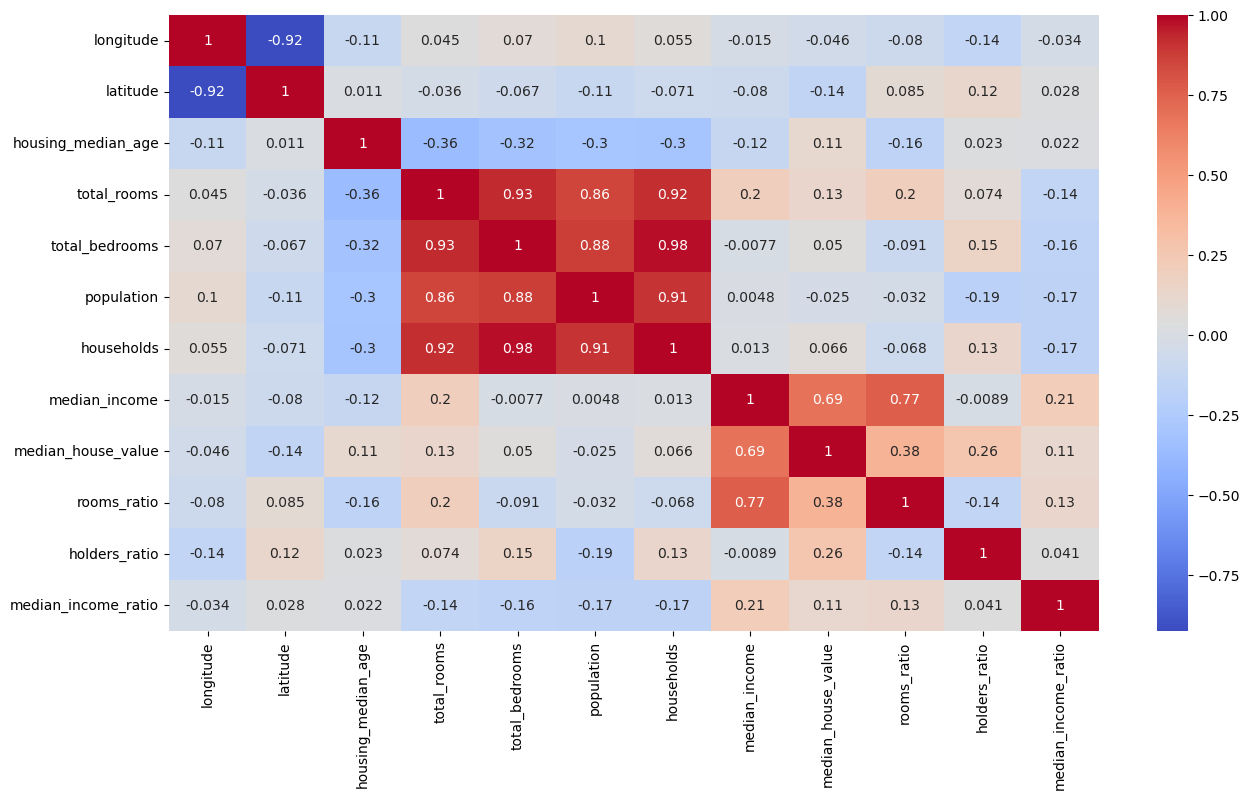

In [12]:
plt.figure(figsize=(15,8))
sns.heatmap(data=raw_data.corr(numeric_only=True), annot=True, cmap="coolwarm")

In [13]:
# total_bedrooms and rooms_ratio : 207 values are mising
raw_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_ratio,holders_ratio,median_income_ratio
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,4.984829,0.364254,0.005309
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,1.171676,0.093364,0.019080
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,1.000000,0.000804,0.000072
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,4.169782,0.304668,0.001761
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,4.922170,0.354847,0.003002
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,5.700364,0.411566,0.005027
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,10.000000,1.444444,1.153854


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>],
       [<Axes: title={'center': 'rooms_ratio'}>,
        <Axes: title={'center': 'holders_ratio'}>,
        <Axes: title={'center': 'median_income_ratio'}>]], dtype=object)

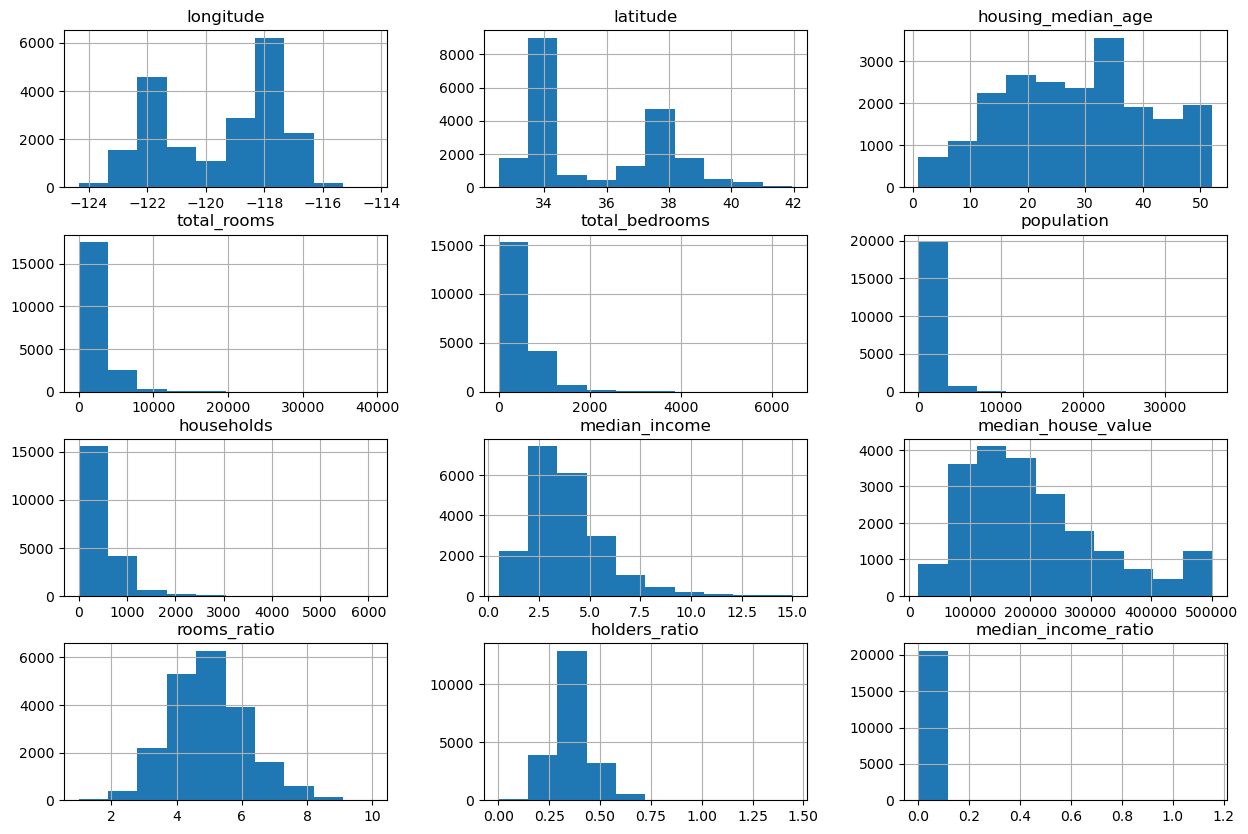

In [14]:
raw_data.hist(figsize=(15,10))

In [15]:
# spliting data into train , cv , test
from sklearn.model_selection import train_test_split

# column transformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
# scale
from sklearn.preprocessing import StandardScaler

# pipeline
from sklearn.pipeline import Pipeline

## 5. Data Splitting

In [16]:
X_raw = raw_data.drop(["median_house_value"], axis=1)
Y_raw = raw_data["median_house_value"]

X_train, X, y_train, y = train_test_split(X_raw, Y_raw, test_size=0.4, random_state=10)
X_cv, X_test, y_cv, y_test = train_test_split(X, y, test_size=0.5, random_state=10)

del X, y 

## 6. Preprocessing Pipeline

In [17]:
cols_log = ["total_rooms", 
            "total_bedrooms", 
            "population",
            "households",                 
            "median_income_ratio"]

cols_normal = ["longitude",
               "latitude",
               "housing_median_age",
               "median_income",
               "rooms_ratio",
               "holders_ratio"
               ]

cols_cat = ["ocean_proximity"]

In [18]:
log_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="mean")),
    ("log", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

normal_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("log", log_pipeline, cols_log),
    ("normal", normal_pipeline, cols_normal),
    ("cat", cat_pipeline, cols_cat)
])

## 7. Model Training

In [19]:
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error,root_mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score

In [20]:
models = [LinearRegression(), 
          RandomForestRegressor(random_state=42),
          DecisionTreeRegressor(random_state=42),
          GradientBoostingRegressor(random_state=42),
          XGBRegressor(random_state=42)]

pipelines = {}
results = []

for model in models:
    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    pipelines[type(model).__name__] = pipeline

    y_hat = pipeline.predict(X_test)
    results.append({
    "Model": type(model).__name__,
    "MSE": mean_squared_error(y_test, y_hat),
    "RMSE": root_mean_squared_error(y_test, y_hat),
    "MAE": mean_absolute_error(y_test, y_hat),
    "MAPE": mean_absolute_percentage_error(y_test, y_hat),
    "R2": r2_score(y_test, y_hat)
})


In [21]:
results = pd.DataFrame(results)
results

,Model,MSE,RMSE,MAE,MAPE,R2
0,LinearRegression,4.429101e+09,66551.490987,48485.524274,0.278845,0.671262
1,RandomForestRegressor,2.454225e+09,49540.136594,32733.474041,0.176871,0.817842
2,DecisionTreeRegressor,5.074789e+09,71237.551674,45738.245155,0.247452,0.623338
3,GradientBoostingRegressor,2.824715e+09,53148.051691,36862.196624,0.201121,0.790343
4,XGBRegressor,2.203541e+09,46941.894217,31181.334403,0.166511,0.836448


## 8. Hyperparameter Tuning

In [22]:
from sklearn.model_selection import GridSearchCV

best_pipeline = pipelines["XGBRegressor"]

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=best_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [23]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('log',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer()),
                                                                                         ('log',
                                                                                          FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['total_rooms',
                                                                          'total_bedrooms',
                                                                          'population',
                                                                          'households',
                                                                          'median_income_ratio']),
                                                                        ('normal',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer...
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.8, 1.0],
                         'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200, 300],
                         'model__subsample': [0.8, 1.0]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [24]:
grid_search.best_params_

{'model__colsample_bytree': 0.8,
 'model__learning_rate': 0.1,
 'model__max_depth': 7,
 'model__n_estimators': 300,
 'model__subsample': 1.0}

In [25]:
grid_search.best_score_

-46542.036111375826

In [26]:
best_model = grid_search.best_estimator_

## 9. Model Evaluation

In [27]:
y_pred = best_model.predict(X_test)

In [28]:
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("R2  :", r2_score(y_test, y_pred))

MSE : 1986848430.9307597
RMSE: 44574.07801548743
MAE : 29421.60795557776
MAPE: 0.1567415453974378
R2  : 0.8525317824811356


## 10. Feature Importance


Feature importance helps us understand which features contribute the most to the XGBoost model's predictions. 
This improves model interpretability and provides insights into the most influential variables.


In [29]:
ohe = best_model.named_steps["preprocess"]\
    .named_transformers_["cat"]\
    .named_steps["onehot"]

In [30]:
cat_feature_names = ohe.get_feature_names_out(cols_cat)

In [31]:
feature_names = (
    cols_log
    + cols_normal
    + list(cat_feature_names)
)

In [32]:
importance = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
12,ocean_proximity_INLAND,0.584776
8,median_income,0.177084
10,holders_ratio,0.040786
15,ocean_proximity_NEAR OCEAN,0.039075
11,ocean_proximity_<1H OCEAN,0.025786
14,ocean_proximity_NEAR BAY,0.024654
5,longitude,0.024644
6,latitude,0.021688
7,housing_median_age,0.018746
9,rooms_ratio,0.014000


In [33]:
importance_df.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
12,ocean_proximity_INLAND,0.584776
8,median_income,0.177084
10,holders_ratio,0.040786
15,ocean_proximity_NEAR OCEAN,0.039075
11,ocean_proximity_<1H OCEAN,0.025786
14,ocean_proximity_NEAR BAY,0.024654
5,longitude,0.024644
6,latitude,0.021688
7,housing_median_age,0.018746
9,rooms_ratio,0.014000


<BarContainer object of 15 artists>

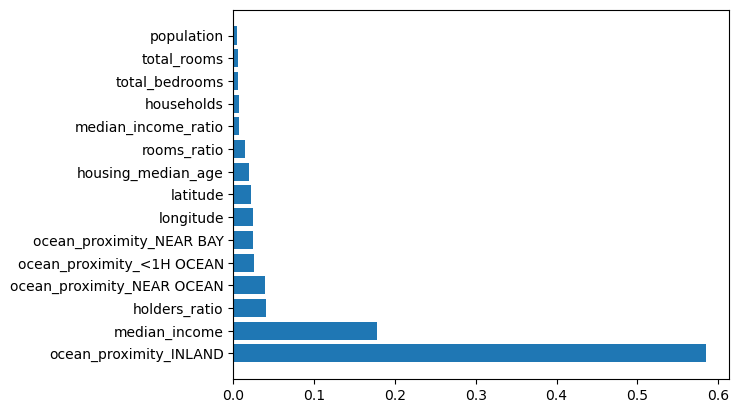

In [34]:
plt.barh(
    importance_df["Feature"][:15],
    importance_df["Importance"][:15]
)

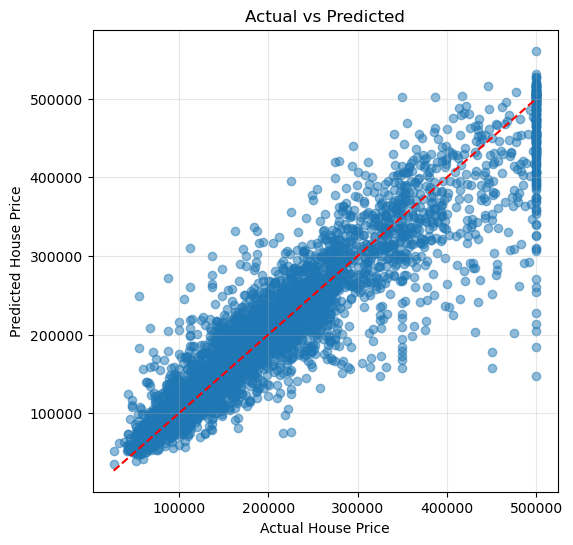

In [35]:
y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted")

plt.grid(alpha=0.3)

plt.show()

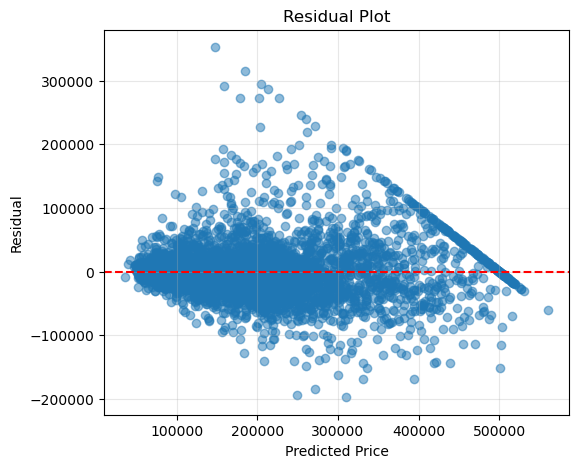

In [36]:
residual = y_test - y_pred

plt.figure(figsize=(6,5))

plt.scatter(y_pred, residual, alpha=0.5)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(alpha=0.3)

plt.show()

## 11. Save Model

In [37]:
import joblib

joblib.dump(best_model, "best_xgboost_pipeline.pkl")

['best_xgboost_pipeline.pkl']

## 12. Load Model and Predict

In [38]:
loaded_model = joblib.load("best_xgboost_pipeline.pkl")

new_data = X_cv.iloc[[1]]
prediction = loaded_model.predict(new_data)

print(
    f"Model Prediction: ${prediction[0]:,.2f}\n"
    f"Actual Value:     ${y_cv.iloc[1]:,.2f}"
)

Model Prediction: $103,761.73
Actual Value:     $99,600.00
